In [2]:
import kagglehub
import json
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_squared_log_error

import matplotlib.pyplot as plt
import seaborn as sns

from regression_task_preprocessing import *

from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR


c:\Users\glebo\Documents\University\Machine Learning\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("../kaggle_token.json", "r") as f:
    kaggle_acc = json.load(f)

os.environ["KAGGLE_USERNAME"] = kaggle_acc["username"]
os.environ["KAGGLE_KEY"] = kaggle_acc["key"]

path = kagglehub.competition_download('uds-machine-learning-2026-regression')

print("Path to competition files:", path)

Path to competition files: C:\Users\glebo\.cache\kagglehub\competitions\uds-machine-learning-2026-regression


In [4]:
train = pd.read_csv(path+"/train.csv")

TARGET = "Rented Bike Count"

train = train.dropna() # figured out in the end that this was here all along. I thought regression data was lucky ... :(
train = train.drop_duplicates(subset=["Date", "Hour"], keep="last")

# X = train.drop(columns=[TARGET, "Date"])
X = train.drop(columns=[TARGET])
y = train[TARGET]

train.head(2)


,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Rented Bike Count
2,2,8/6/2018,21,21.2,77,1.7,638,16.9,0.0,0.0,0.0,Summr,No Holiday,Yes,13081158,2477
3,3,3/2/2018,23,-10.0,48,2.6,2000,-18.9,0.0,0.0,0.0,Winteer,No Holiday,Yes,807953,88


In [5]:
# =========================
# 2. COLUMN SPLIT
# =========================
X = engineer_features(X)
X = drop_unnecessary_columns(X)
X = filter_invalid(X)
y = y.loc[X.index]


In [6]:
debug_df = X.copy()
debug_df[TARGET] = y
debug_df.to_csv("preprocessed_debug.csv", index=False)
print("Saved preprocessed (pre-scaling) data to preprocessed_debug.csv", debug_df.shape)
debug_df.head()


Saved preprocessed (pre-scaling) data to preprocessed_debug.csv (4726, 23)


,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,...,Temperature x Humidity,Wind Chill,Hour sin,Hour cos,Fog Risk,Rainfall accumulation 3h,Temperature change 3h,Temperature rolling 3h avg,Wind speed rolling 3h avg,Rented Bike Count
2,21,21.2,77,1.7,638,16.9,0.00,0.0,0.0,Summr,...,1632.4,21.200000,-0.707107,7.071068e-01,0,0.0,-5.4,23.566667,1.933333,2477
3,23,-10.0,48,2.6,2000,-18.9,0.00,0.0,0.0,Winteer,...,-480.0,-15.027489,-0.258819,9.659258e-01,0,0.0,-1.5,-9.600000,2.766667,88
4,18,33.9,42,2.0,1969,19.1,1.25,0.0,0.0,Sumer,...,1423.8,33.900000,-1.000000,-1.836970e-16,0,0.0,0.5,34.100000,2.166667,2584
5,18,26.3,55,3.2,1119,16.5,0.64,0.0,0.0,Summer,...,1446.5,26.300000,-1.000000,-1.836970e-16,0,0.0,0.5,27.566667,3.166667,2328
6,1,23.1,66,1.6,2000,16.3,0.00,0.0,0.0,Sumer,...,1524.6,23.100000,0.258819,9.659258e-01,0,0.2,-3.6,20.133333,1.600000,831


In [7]:


# skewed_cols = ["Wind speed", "Solar Radiation"]
# skewed_cols = ["Wind speed"]
skewed_cols = []
num_cols = X.select_dtypes(include="number").columns
num_cols = [c for c in num_cols if c not in skewed_cols] 
cat_cols = X.select_dtypes(include=["object", "str"]).columns
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

# =========================
# 3. PREPROCESSOR
# =========================

numeric_transformer = Pipeline([("scaler", StandardScaler())])

skewed_transformer = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=True)),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("fix_season", FunctionTransformer(fix_season)),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")),
])

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, num_cols),
        ("skewed", skewed_transformer, skewed_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


# =========================
# 4. PIPELINE
# =========================
ridge_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge())
])

gb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor())
])

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror"
    ))
])

svm_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", SVR(kernel="rbf"))
])

# =========================
# 5. GRID SEARCH
# =========================
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid={
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    },
    scoring="neg_root_mean_squared_error",
    cv=5
)

gb_grid = GridSearchCV(
    gb_pipeline,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    scoring="neg_root_mean_squared_error",
    cv=5
)

xgb_grid = GridSearchCV(
    xgb_pipeline,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    },
    scoring="neg_root_mean_squared_error",
    cv=5
)

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid={
        "model__C": [1, 10, 100],
        "model__gamma": ["scale", 0.01, 0.1],
        "model__epsilon": [0.1, 1]
    },
    scoring="neg_root_mean_squared_error",
    cv=5
)

ridge_grid.fit(X, y)
# gb_grid.fit(X, y)
xgb_grid.fit(X, y)
# svm_grid.fit(X, y)

# =========================
# 6. RESULTS
# =========================

models = {
    "Ridge": ridge_grid,
    # "Gradient Boosting": gb_grid,
    "XGBoost": xgb_grid,
    # "SVM (RBF)": svm_grid
}

results = {}

for name, grid in models.items():
    cv_pred = cross_val_predict(grid.best_estimator_, X, y, cv=5)
    cv_pred = np.clip(cv_pred, a_min=0, a_max=None)

    results[name] = {
        "best_model": grid.best_estimator_,
        "best_params": grid.best_params_,
        "cv_rmse": -grid.best_score_,
        "msle": mean_squared_log_error(y, cv_pred)
    }
    
    print(f"\n{name}")
    print("-" * len(name))
    print("Best parameters:", grid.best_params_)
    print("Best CV RMSE:", -grid.best_score_)
    print("MSLE:", results[name]["msle"])


# =========================
# 7. FINAL MODELS
# =========================

final_models = {}

for name, result in results.items():
    final_model = result["best_model"]
    final_model.fit(X, y)
    final_models[name] = final_model

    print(f"\n{name} final model fitted.")

Numeric: ['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Dew Point Depression', 'Temperature x Humidity', 'Wind Chill', 'Hour sin', 'Hour cos', 'Fog Risk', 'Rainfall accumulation 3h', 'Temperature change 3h', 'Temperature rolling 3h avg', 'Wind speed rolling 3h avg']
Categorical: Index(['Seasons', 'Holiday', 'Functioning Day'], dtype='str')

Ridge
-----
Best parameters: {'model__alpha': 1}
Best CV RMSE: 426.26658950627586
MSLE: 2.7193954010755683

XGBoost
-------
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV RMSE: 237.14066467285156
MSLE: 0.8077501654624939

Ridge final model fitted.

XGBoost final model fitted.


# Submission

In [8]:
import pandas as pd
import numpy as np

# =========================
# 11. TEST PREDICTIONS
# =========================
test = pd.read_csv(path+"/test.csv")

# Drop non-feature columns safely
test_X = engineer_features(test)
test_X = drop_unnecessary_columns(test_X)

# Predict using trained pipeline
best_model_name = min(results, key=lambda name: results[name]["cv_rmse"])
final_pipeline = final_models[best_model_name]

print(f"Using best model: {best_model_name}")
print(f"--> CV RMSE: {results[best_model_name]['cv_rmse']:.4f}")
print(f"--> CV MSLE: {results[best_model_name]['msle']:.4f}")
print(f"--> Best params: {results[best_model_name]['best_params']}")

preds = final_pipeline.predict(test_X)

# If using MSLE, ensure no negative predictions
preds = np.clip(preds, 0, None)

# =========================
# 12. SUBMISSION
# =========================
submission = pd.read_csv(path+"/sample_submission.csv")

submission["Rented Bike Count"] = preds

submission.to_csv("my_first_submission.csv", index=False)

print("submission created successfully")
print(submission.head())

Using best model: XGBoost
--> CV RMSE: 237.1407
--> CV MSLE: 0.8078
--> Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
submission created successfully
   Kaggle_ID  Rented Bike Count
0          0         292.510895
1          1         548.870667
2          2         232.484741
3          3         262.194763
4          4         240.213852


In [9]:
print(submission.describe)

<bound method NDFrame.describe of       Kaggle_ID  Rented Bike Count
0             0         292.510895
1             1         548.870667
2             2         232.484741
3             3         262.194763
4             4         240.213852
...         ...                ...
2623       2623         797.597412
2624       2624        1103.887085
2625       2625         728.930481
2626       2626         871.563599
2627       2627         792.638367

[2628 rows x 2 columns]>


In [10]:
import pandas as pd
import numpy as np

# =========================
# 11. TEST PREDICTIONS
# =========================
test = pd.read_csv(path+"/test.csv")
test_X = test
print(test_X.head(2))
test_X = engineer_features(test_X)
test_X = drop_unnecessary_columns(test_X)
test_X.head(2)


   Kaggle_ID       Date  Hour  Temperature  Humidity  Wind speed  Visibility  \
0          0  1/12/2017    15          2.1        36         3.2        2000   
1          1  1/12/2017    18          0.6        66         1.4        2000   

   Dew point temperature  Solar Radiation  Rainfall  Snowfall Seasons  \
0                  -11.4             0.54       0.0       0.0  Winter   
1                   -5.0             0.00       0.0       0.0  Winter   

      Holiday Functioning Day  Record_id  
0  No Holiday             Yes     425412  
1  No Holiday             Yes     729632  


,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,...,Dew Point Depression,Temperature x Humidity,Wind Chill,Hour sin,Hour cos,Fog Risk,Rainfall accumulation 3h,Temperature change 3h,Temperature rolling 3h avg,Wind speed rolling 3h avg
0,15,2.1,36,3.2,2000,-11.4,0.54,0.0,0.0,Winter,...,13.5,75.6,-1.154719,-0.707107,-7.071068e-01,0,0.0,0.0,2.10,3.2
1,18,0.6,66,1.4,2000,-5.0,0.00,0.0,0.0,Winter,...,5.6,39.6,-0.927124,-1.000000,-1.836970e-16,0,0.0,0.0,1.35,2.3


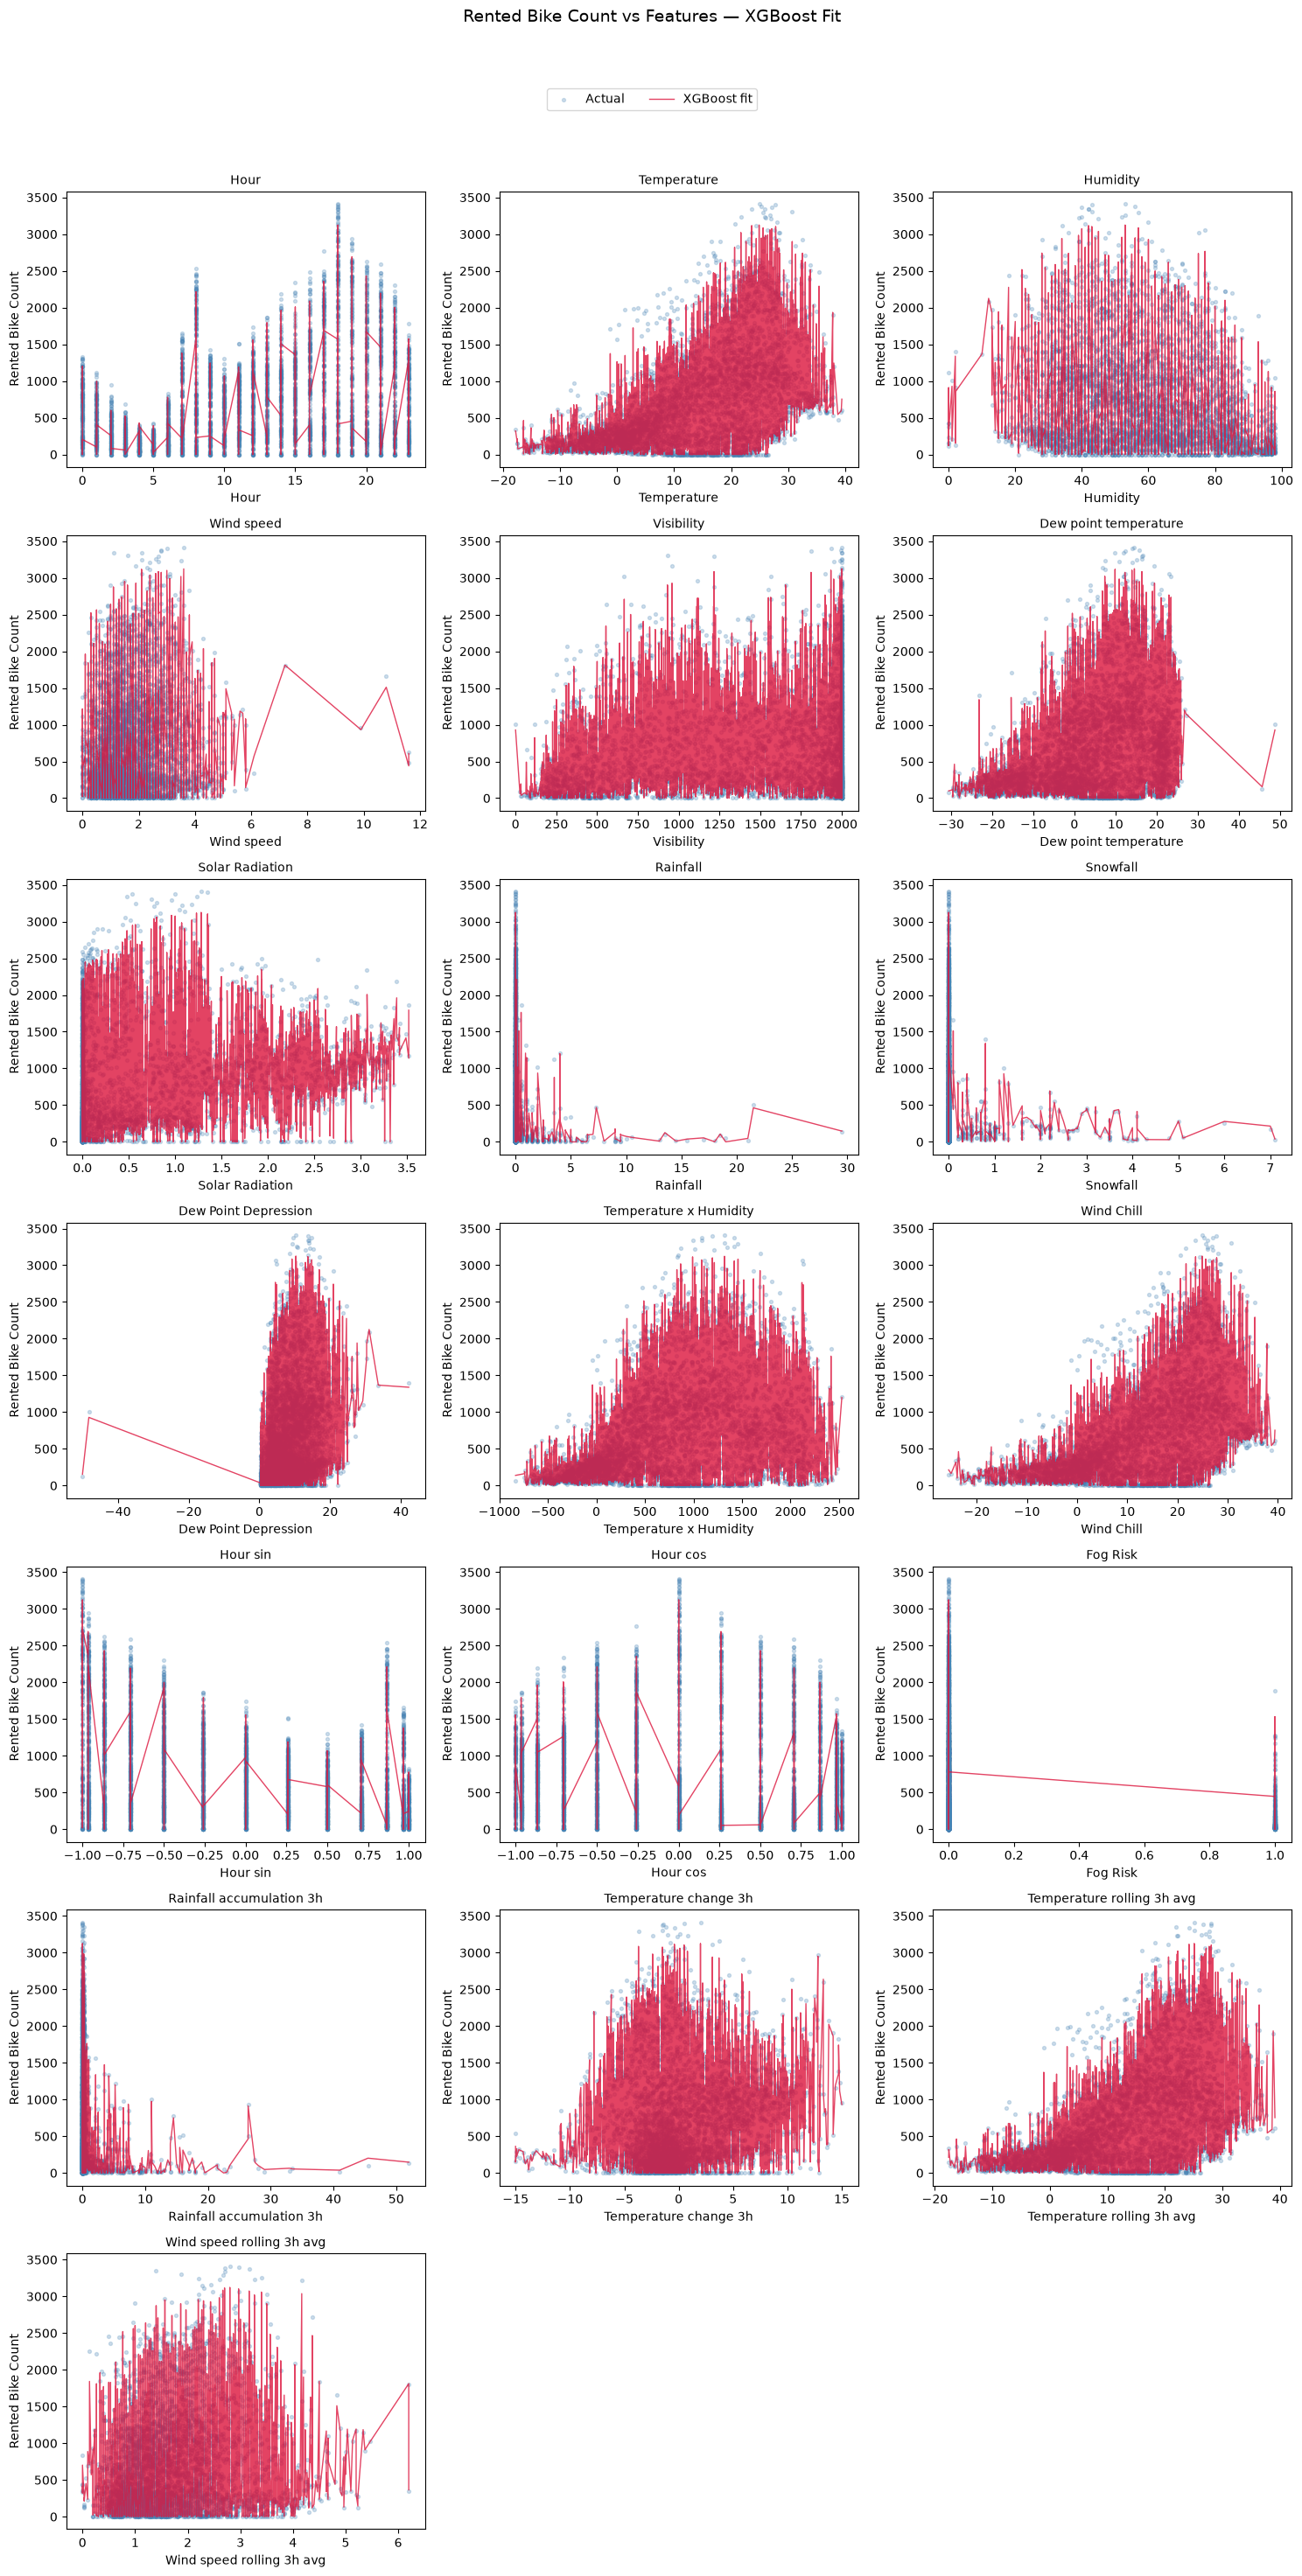

In [11]:
# Get predictions from the best model (already fitted on full X, y in cell 5)
y_pred = final_pipeline.predict(X)
y_pred = np.clip(y_pred, 0, None)

feature_cols = list(num_cols)  # numeric features engineered earlier

n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, feature in enumerate(feature_cols):
    ax = axes[i]

    # Actual data points
    ax.scatter(X[feature], y, s=8, alpha=0.25, color="steelblue", label="Actual")

    # Model fit: sort by feature value so the predicted line is readable
    order = np.argsort(X[feature].values)
    ax.plot(
        X[feature].values[order],
        y_pred[order],
        color="crimson",
        linewidth=1,
        alpha=0.8,
        label=f"{best_model_name} fit",
    )

    ax.set_xlabel(feature)
    ax.set_ylabel(TARGET)
    ax.set_title(feature, fontsize=10)

# Hide any unused subplots
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"{TARGET} vs Features — {best_model_name} Fit", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
from sklearn import set_config
set_config(display="diagram")

final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Hour','Temperature','Humidity',...,'Temperature change 3h', 'Temperature rolling 3h avg','Wind speed rolling 3h avg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('skewed', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto